In [44]:
import gymnasium as gym
import numpy as np
import yaml

In [45]:
with open("env.yaml","r",encoding="utf8") as file:
    conf = yaml.safe_load(file)

conf

{'env': {'rows': 5,
  'cols': 5,
  'slip_probability': 0.0,
  'step_reward': -0.04,
  'goal_reward': 1.0},
 'training': {'gamma': 0.95,
  'alpha': 0.1,
  'epsilon_start': 1.0,
  'epsilon_end': 0.05,
  'epsilon_decay': 0.995,
  'episodes': 3000,
  'seed': 42}}

In [46]:
gamma = conf["training"]["gamma"]
alpha= conf["training"]["alpha"]
eps_start = conf["training"]["epsilon_start"]
eps_end = conf["training"]["epsilon_end"]
eps_decay = conf["training"]["epsilon_decay"]
episodes = conf["training"]["episodes"]

In [47]:
class GridWorld:
    def __init__(self):
        self.size = 5

        self.start = (0,0)
        self.goal = (4,4)

        self.obstracles = {
            (1,1),
            (1,3),
            (2,3),
            (3,1),
            (3,4)
        }

        self.agent = self.start

    def reset(self):
        self.agent = self.start
        return self.agent

    def step(self,action):
        row, col = self.agent

        if action == 0:       # вверх
            new_position = (row - 1, col)

        elif action == 1:     # вправо
            new_position = (row, col + 1)

        elif action == 2:     # вниз
            new_position = (row + 1, col)

        elif action == 3:     # влево
            new_position = (row, col - 1)

        if not (0<=new_position[0] <self.size and 0<=new_position[1]< self.size):
            return self.agent, -0.5, False

        if new_position in self.obstracles:
            return self.agent, -0.5 ,False

        self.agent = new_position

        if self.agent == self.goal:
            return self.agent,1.0, True

        return self.agent,-0.04,False



In [48]:
def chose_action(Q, state, epsilon):

    if np.random.random() < epsilon:
        # Исследование
        return np.random.randint(4)

    else:
        # Используем лучшее известное действие
        return np.argmax(Q[state])

In [49]:
sreda = GridWorld()

state = sreda.reset()

print(state)

(0, 0)


In [50]:
actions = [
    1,  # вправо
    1,  # вправо
    1,  # вправо
    1,  # вправо
    2,  # вниз
    2,
    2,
    2
]

for action in actions:
    state, reward ,done = sreda.step(action)
    print(
        "state:", state,
        "reward:", reward,
        "done:", done
    )

    if done:
        break


state: (0, 1) reward: -0.04 done: False
state: (0, 2) reward: -0.04 done: False
state: (0, 3) reward: -0.04 done: False
state: (0, 4) reward: -0.04 done: False
state: (1, 4) reward: -0.04 done: False
state: (2, 4) reward: -0.04 done: False
state: (2, 4) reward: -0.5 done: False
state: (2, 4) reward: -0.5 done: False


In [51]:
Q = np.zeros((5, 5, 4))

for epoch in range(episodes):
    state = sreda.reset()
    done = False

    while not done:
        action = chose_action(Q, state, eps_start)

        next_state, reward, done = sreda.step(action)

        if done:
            target = reward
        else:
            target = reward + gamma * np.max(Q[next_state])

        Q[state][action] += alpha * (
            target - Q[state][action]
        )

        state = next_state

    eps = max(eps_end, eps_start * eps_decay)

    print(f"Episode {epoch} complete")

Episode 0 complete
Episode 1 complete
Episode 2 complete
Episode 3 complete
Episode 4 complete
Episode 5 complete
Episode 6 complete
Episode 7 complete
Episode 8 complete
Episode 9 complete
Episode 10 complete
Episode 11 complete
Episode 12 complete
Episode 13 complete
Episode 14 complete
Episode 15 complete
Episode 16 complete
Episode 17 complete
Episode 18 complete
Episode 19 complete
Episode 20 complete
Episode 21 complete
Episode 22 complete
Episode 23 complete
Episode 24 complete
Episode 25 complete
Episode 26 complete
Episode 27 complete
Episode 28 complete
Episode 29 complete
Episode 30 complete
Episode 31 complete
Episode 32 complete
Episode 33 complete
Episode 34 complete
Episode 35 complete
Episode 36 complete
Episode 37 complete
Episode 38 complete
Episode 39 complete
Episode 40 complete
Episode 41 complete
Episode 42 complete
Episode 43 complete
Episode 44 complete
Episode 45 complete
Episode 46 complete
Episode 47 complete
Episode 48 complete
Episode 49 complete
Episode 50

In [52]:
for row in range(5):
    for col in range(5):
        print(f"State ({row}, {col}): {Q[row, col]}")

State (0, 0): [-0.06584322  0.45700713  0.45700713 -0.06584322]
State (0, 1): [-0.00299287  0.5231654  -0.00299287  0.39415678]
State (0, 2): [0.0631654  0.45700713 0.59280569 0.45700713]
State (0, 3): [-0.00299287  0.39415678 -0.00299287  0.5231654 ]
State (0, 4): [-0.06584322 -0.06584322  0.33444894  0.45700713]
State (1, 0): [ 0.39415678 -0.00299287  0.5231654  -0.00299287]
State (1, 1): [0. 0. 0. 0.]
State (1, 2): [0.5231654  0.13280569 0.66611125 0.13280569]
State (1, 3): [0. 0. 0. 0.]
State (1, 4): [ 0.39415678 -0.12555106  0.27772649 -0.12555106]
State (2, 0): [0.45700713 0.59280569 0.59280569 0.0631654 ]
State (2, 1): [0.13280569 0.66611125 0.13280569 0.5231654 ]
State (2, 2): [0.59280569 0.20611125 0.743275   0.59280569]
State (2, 3): [0. 0. 0. 0.]
State (2, 4): [ 0.33444894 -0.18227351 -0.18227351 -0.18227351]
State (3, 0): [0.5231654  0.13280569 0.66611125 0.13280569]
State (3, 1): [0. 0. 0. 0.]
State (3, 2): [0.66611125 0.8245     0.8245     0.283275  ]
State (3, 3): [0.364

In [53]:
print(np.argmax(Q, axis=2))

[[1 1 2 3 3]
 [2 0 2 0 0]
 [1 1 2 0 0]
 [2 0 1 2 0]
 [1 1 1 1 0]]


In [54]:
Q_1 = np.zeros((5,5,4))
sreda_2 = GridWorld()

for epoch in range(episodes):
    state = sreda_2.reset()
    done = False

    while not done:
        action = chose_action(Q_1, state, eps_start)

        next_state,reward,done = sreda_2.step(action)
        next_action = chose_action(Q_1, next_state, eps_start)

        Q_1[state][action] += alpha*(reward + gamma*Q_1[next_state][next_action] - Q_1[state][action])

        state = next_state

    eps_start = max(eps_start*eps_decay, eps_end)

    print(f"Episode {epoch} complete")


Episode 0 complete
Episode 1 complete
Episode 2 complete
Episode 3 complete
Episode 4 complete
Episode 5 complete
Episode 6 complete
Episode 7 complete
Episode 8 complete
Episode 9 complete
Episode 10 complete
Episode 11 complete
Episode 12 complete
Episode 13 complete
Episode 14 complete
Episode 15 complete
Episode 16 complete
Episode 17 complete
Episode 18 complete
Episode 19 complete
Episode 20 complete
Episode 21 complete
Episode 22 complete
Episode 23 complete
Episode 24 complete
Episode 25 complete
Episode 26 complete
Episode 27 complete
Episode 28 complete
Episode 29 complete
Episode 30 complete
Episode 31 complete
Episode 32 complete
Episode 33 complete
Episode 34 complete
Episode 35 complete
Episode 36 complete
Episode 37 complete
Episode 38 complete
Episode 39 complete
Episode 40 complete
Episode 41 complete
Episode 42 complete
Episode 43 complete
Episode 44 complete
Episode 45 complete
Episode 46 complete
Episode 47 complete
Episode 48 complete
Episode 49 complete
Episode 50

In [55]:
for row in range(5):
    for col in range(5):
        print(f"State ({row}, {col}): {Q[row, col]}")

State (0, 0): [-0.06584322  0.45700713  0.45700713 -0.06584322]
State (0, 1): [-0.00299287  0.5231654  -0.00299287  0.39415678]
State (0, 2): [0.0631654  0.45700713 0.59280569 0.45700713]
State (0, 3): [-0.00299287  0.39415678 -0.00299287  0.5231654 ]
State (0, 4): [-0.06584322 -0.06584322  0.33444894  0.45700713]
State (1, 0): [ 0.39415678 -0.00299287  0.5231654  -0.00299287]
State (1, 1): [0. 0. 0. 0.]
State (1, 2): [0.5231654  0.13280569 0.66611125 0.13280569]
State (1, 3): [0. 0. 0. 0.]
State (1, 4): [ 0.39415678 -0.12555106  0.27772649 -0.12555106]
State (2, 0): [0.45700713 0.59280569 0.59280569 0.0631654 ]
State (2, 1): [0.13280569 0.66611125 0.13280569 0.5231654 ]
State (2, 2): [0.59280569 0.20611125 0.743275   0.59280569]
State (2, 3): [0. 0. 0. 0.]
State (2, 4): [ 0.33444894 -0.18227351 -0.18227351 -0.18227351]
State (3, 0): [0.5231654  0.13280569 0.66611125 0.13280569]
State (3, 1): [0. 0. 0. 0.]
State (3, 2): [0.66611125 0.8245     0.8245     0.283275  ]
State (3, 3): [0.364

In [56]:
print(np.argmax(Q_1,axis=2))

[[2 1 2 3 3]
 [2 0 2 0 0]
 [1 1 2 0 0]
 [2 0 2 2 0]
 [1 1 1 1 0]]


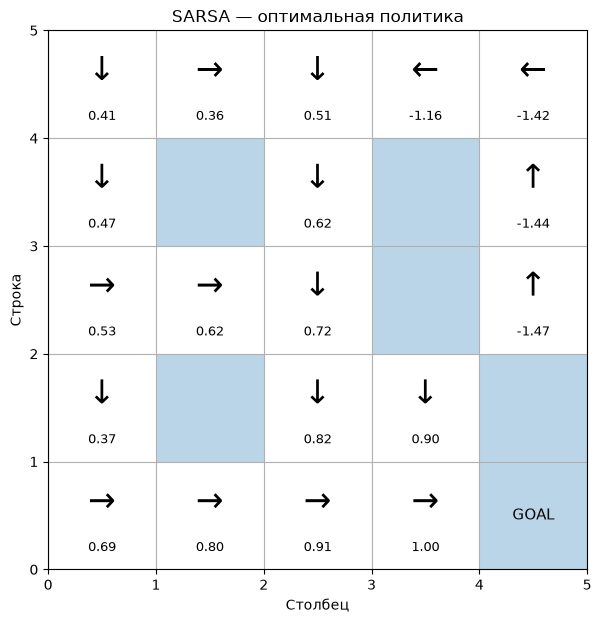

In [57]:
import matplotlib.pyplot as plt

best_actions = np.argmax(Q_1, axis=2)
best_values = np.max(Q_1, axis=2)

arrows = {
    0: "↑",
    1: "→",
    2: "↓",
    3: "←"
}

fig, ax = plt.subplots(figsize=(7, 7))

ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_xticks(np.arange(6))
ax.set_yticks(np.arange(6))
ax.grid(True)
ax.set_aspect("equal")

# Препятствия
for obstacle in sreda_2.obstracles:
    r, c = obstacle
    ax.add_patch(
        plt.Rectangle((c, 4-r), 1, 1, alpha=0.3)
    )

# Цель
r, c = sreda_2.goal
ax.add_patch(
    plt.Rectangle((c, 4-r), 1, 1, alpha=0.3)
)

# Стрелки и Q-значения
for r in range(5):
    for c in range(5):

        if (r, c) in sreda_2.obstracles:
            continue

        x = c
        y = 4 - r

        if (r, c) == sreda_2.goal:
            ax.text(
                x + 0.5, y + 0.5,
                "GOAL",
                ha="center",
                va="center",
                fontsize=11
            )
        else:
            action = best_actions[r, c]
            value = best_values[r, c]

            ax.text(
                x + 0.5, y + 0.62,
                arrows[action],
                ha="center",
                va="center",
                fontsize=24
            )

            ax.text(
                x + 0.5, y + 0.2,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=9
            )

ax.set_title("SARSA — оптимальная политика")
ax.set_xlabel("Столбец")
ax.set_ylabel("Строка")

plt.show()

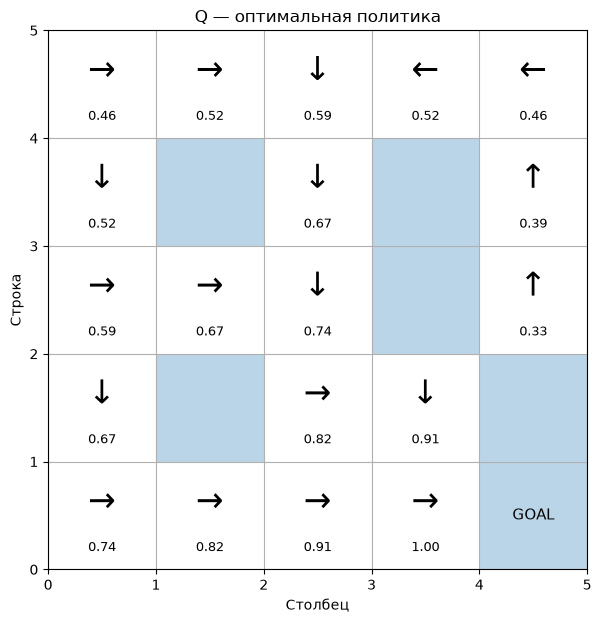

In [58]:
best_actions = np.argmax(Q, axis=2)
best_values = np.max(Q, axis=2)

arrows = {
    0: "↑",
    1: "→",
    2: "↓",
    3: "←"
}

fig, ax = plt.subplots(figsize=(7, 7))

ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_xticks(np.arange(6))
ax.set_yticks(np.arange(6))
ax.grid(True)
ax.set_aspect("equal")

# Препятствия
for obstacle in sreda.obstracles:
    r, c = obstacle
    ax.add_patch(
        plt.Rectangle((c, 4-r), 1, 1, alpha=0.3)
    )

# Цель
r, c = sreda.goal
ax.add_patch(
    plt.Rectangle((c, 4-r), 1, 1, alpha=0.3)
)

# Стрелки и Q-значения
for r in range(5):
    for c in range(5):

        if (r, c) in sreda.obstracles:
            continue

        x = c
        y = 4 - r

        if (r, c) == sreda.goal:
            ax.text(
                x + 0.5, y + 0.5,
                "GOAL",
                ha="center",
                va="center",
                fontsize=11
            )
        else:
            action = best_actions[r, c]
            value = best_values[r, c]

            ax.text(
                x + 0.5, y + 0.62,
                arrows[action],
                ha="center",
                va="center",
                fontsize=24
            )

            ax.text(
                x + 0.5, y + 0.2,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=9
            )

ax.set_title("Q — оптимальная политика")
ax.set_xlabel("Столбец")
ax.set_ylabel("Строка")

plt.show()